📉 INSIGHT 2: OPERATIONAL VULNERABILITY - ADDRESS DEFECT RATE
✅ File found at: us_export_compliance_data_with_risk.csv

📦 Analyzing 5,000 shipments with dates from 2025-07-07 to 2026-07-06

📊 ADDRESS DEFECT RATE BY BUSINESS UNIT:


,business_unit,total_exports,address_red_flags,address_defect_rate_pct
1,US-ConsumerElectronics,1582,43,2.72
2,US-IndustrialEquipment,966,19,1.97
4,US-Pharmaceuticals,478,9,1.88
3,US-MedicalDevices,1239,21,1.69
0,US-AerospaceParts,735,9,1.22



⚠️ HIGHEST DEFECT RATE: US-ConsumerElectronics
   Defect Rate: 2.72%
   Total Address Red Flags: 43

📊 OVERALL ADDRESS DEFECT RATE: 2.02%

📊 DEFECT DISTRIBUTION BY DESTINATION COUNTRY:


,country,defect_count,percentage
0,NORTH KOREA,37,36.6
1,IRAN,25,24.8
2,CRIMEA,24,23.8
3,SYRIA,15,14.9



📅 MONTHLY DEFECT RATE BY BUSINESS UNIT:


exporter_business_unit,US-AerospaceParts,US-ConsumerElectronics,US-IndustrialEquipment,US-MedicalDevices,US-Pharmaceuticals
shipment_month,,,,,
2026-02,0.000000,0.000000,2.083333,1.020408,0.000000
2026-03,1.470588,0.694444,4.477612,0.000000,0.000000
2026-04,0.000000,3.478261,2.298851,4.672897,2.702703
2026-05,1.587302,3.571429,2.127660,2.678571,3.030303
2026-06,4.000000,0.877193,0.000000,1.052632,0.000000
2026-07,0.000000,12.000000,8.333333,3.225806,0.000000


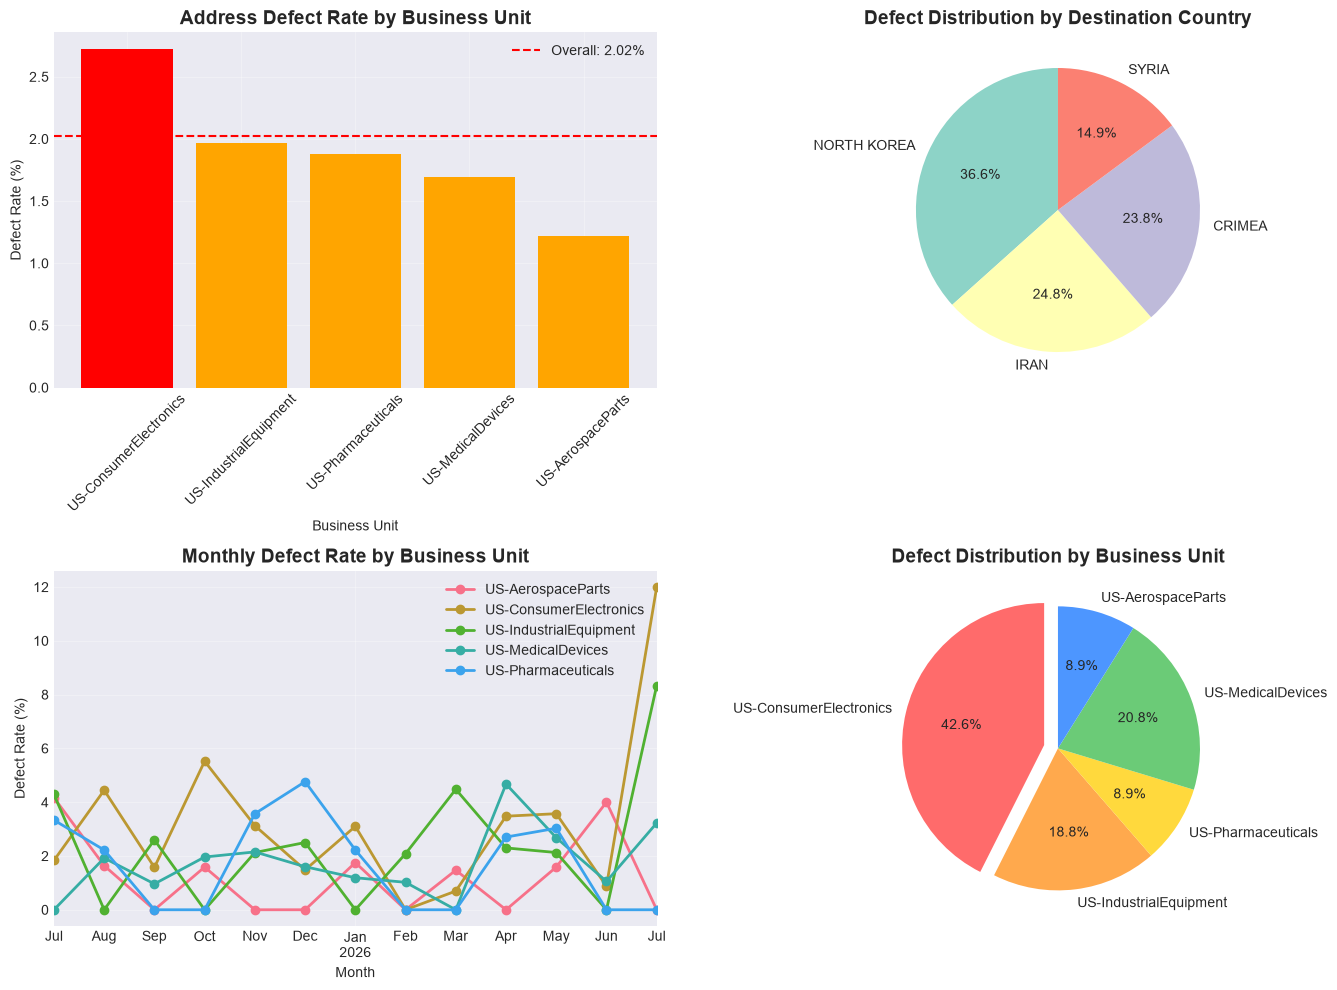


💾 Saved: output/insight2_address_defects.png

📊 EXECUTIVE SUMMARY - ADDRESS DEFECT ANALYSIS

   OPERATIONAL IMPACT:
   ├─ Total Address Red Flags: 101
   ├─ Overall Defect Rate: 2.02%
   └─ Highest Risk Business Unit: US-ConsumerElectronics (2.72%)

   TOP DESTINATION COUNTRIES:
   ├─ NORTH KOREA: 37 defects (36.6%)
   ├─ IRAN: 25 defects (24.8%)
   └─ CRIMEA: 24 defects (23.8%)

   RECOMMENDATIONS:
   1. Deploy automated address validation for US-ConsumerElectronics (2.72% defect rate)
   2. Implement real-time OFAC screening for high-risk destinations
   3. Provide targeted data entry training to high-risk business units


✅ INSIGHT 2 COMPLETE!


In [2]:
# %% [markdown]
# # 📉 Insight 2: Operational Vulnerability - Address Defect Rate
# 
# **Purpose**: Identify which business units submit the highest rate of unverified addresses
# 
# **Key Questions**:
# - Which business units have the highest address defect rates?
# - How do defect rates trend over time?
# - What are the most common sanctioned destinations?

# %% [code]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("📉 INSIGHT 2: OPERATIONAL VULNERABILITY - ADDRESS DEFECT RATE")
print("="*70)

# %% [code]
# Load the dataset with risk flags
# Try multiple possible paths
possible_paths = [
    '../us_export_compliance_data_with_risk.csv',  # If running from notebooks folder
    'us_export_compliance_data_with_risk.csv',     # If running from main folder
    '../data/us_export_compliance_data_with_risk.csv',  # If in data folder
]

df = None
for path in possible_paths:
    try:
        df = pd.read_csv(path, parse_dates=['shipment_date', 'clearance_date'])
        print(f"✅ File found at: {path}")
        break
    except FileNotFoundError:
        continue

if df is None:
    print("❌ Could not find us_export_compliance_data_with_risk.csv")
    print("Current working directory:", os.getcwd())
    print("Files in current directory:")
    print(os.listdir('.'))
    raise FileNotFoundError("CSV file not found")

print(f"\n📦 Analyzing {len(df):,} shipments with dates from {df['shipment_date'].min().strftime('%Y-%m-%d')} to {df['shipment_date'].max().strftime('%Y-%m-%d')}")

# %% [markdown]
# ## Address Defect Analysis

# %% [code]
# Aggregate address defects by business unit
exporter_risk = df.groupby('exporter_business_unit').agg({
    'shipment_id': 'count',
    'address_red_flag': 'sum'
}).reset_index()

exporter_risk.columns = ['business_unit', 'total_exports', 'address_red_flags']
exporter_risk['address_defect_rate_pct'] = (
    (exporter_risk['address_red_flags'] / exporter_risk['total_exports']) * 100
).round(2)

exporter_risk = exporter_risk.sort_values('address_defect_rate_pct', ascending=False)

print("\n📊 ADDRESS DEFECT RATE BY BUSINESS UNIT:")
display(exporter_risk)

# Identify worst performer
worst_unit = exporter_risk.iloc[0]['business_unit']
worst_rate = exporter_risk.iloc[0]['address_defect_rate_pct']
worst_count = exporter_risk.iloc[0]['address_red_flags']

print(f"\n⚠️ HIGHEST DEFECT RATE: {worst_unit}")
print(f"   Defect Rate: {worst_rate}%")
print(f"   Total Address Red Flags: {worst_count}")

# Calculate overall defect rate
total_address_defects = exporter_risk['address_red_flags'].sum()
overall_defect_rate = (total_address_defects / len(df)) * 100
print(f"\n📊 OVERALL ADDRESS DEFECT RATE: {overall_defect_rate:.2f}%")

# %% [markdown]
# ## Defect Distribution by Country

# %% [code]
# Analyze defects by destination country
country_defects = df[df['address_red_flag']]['consignee_country'].value_counts().reset_index()
country_defects.columns = ['country', 'defect_count']
country_defects['percentage'] = (country_defects['defect_count'] / total_address_defects * 100).round(1)

print("\n📊 DEFECT DISTRIBUTION BY DESTINATION COUNTRY:")
display(country_defects)

# %% [markdown]
# ## Monthly Trend Analysis

# %% [code]
# Monthly defect rate by business unit
df['shipment_month'] = df['shipment_date'].dt.to_period('M')
monthly_defects = df.groupby(['shipment_month', 'exporter_business_unit'])['address_red_flag'].mean().unstack() * 100

print("\n📅 MONTHLY DEFECT RATE BY BUSINESS UNIT:")
display(monthly_defects.tail(6))

# %% [markdown]
# ## Visualization

# %% [code]
# Create output folder if it doesn't exist
if not os.path.exists('../output'):
    os.makedirs('../output')
    print("✅ Created output folder")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Defect rates by business unit (bar chart)
colors = ['red' if rate > 2 else 'orange' if rate > 1 else 'green' 
          for rate in exporter_risk['address_defect_rate_pct']]
axes[0,0].bar(exporter_risk['business_unit'], exporter_risk['address_defect_rate_pct'], color=colors)
axes[0,0].set_title('Address Defect Rate by Business Unit', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Business Unit')
axes[0,0].set_ylabel('Defect Rate (%)')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].axhline(y=overall_defect_rate, color='red', linestyle='--', 
                  label=f'Overall: {overall_defect_rate:.2f}%')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Defect distribution by country (pie chart)
if len(country_defects) > 0:
    colors_pie = sns.color_palette("Set3", len(country_defects))
    axes[0,1].pie(country_defects['defect_count'], 
                  labels=country_defects['country'],
                  autopct='%1.1f%%',
                  colors=colors_pie,
                  startangle=90)
    axes[0,1].set_title('Defect Distribution by Destination Country', fontsize=14, fontweight='bold')

# 3. Monthly trend (line chart)
if len(monthly_defects) > 0:
    monthly_defects.plot(kind='line', ax=axes[1,0], marker='o', linewidth=2)
    axes[1,0].set_title('Monthly Defect Rate by Business Unit', fontsize=14, fontweight='bold')
    axes[1,0].set_xlabel('Month')
    axes[1,0].set_ylabel('Defect Rate (%)')
    axes[1,0].legend(loc='upper right')
    axes[1,0].grid(True, alpha=0.3)

# 4. Defect distribution by business unit (pie chart)
bu_defects = exporter_risk[exporter_risk['address_red_flags'] > 0]
if len(bu_defects) > 0:
    colors_pie2 = ['#ff6b6b', '#ffa94d', '#ffd93d', '#6bcb77', '#4d96ff']
    explode = [0.1 if i == 0 else 0 for i in range(len(bu_defects))]
    axes[1,1].pie(bu_defects['address_red_flags'], 
                  labels=bu_defects['business_unit'],
                  autopct='%1.1f%%',
                  colors=colors_pie2[:len(bu_defects)],
                  explode=explode,
                  startangle=90)
    axes[1,1].set_title('Defect Distribution by Business Unit', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../output/insight2_address_defects.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💾 Saved: output/insight2_address_defects.png")

# %% [markdown]
# ## Executive Summary

# %% [code]
print("\n" + "="*70)
print("📊 EXECUTIVE SUMMARY - ADDRESS DEFECT ANALYSIS")
print("="*70)

print(f"""
   OPERATIONAL IMPACT:
   ├─ Total Address Red Flags: {total_address_defects}
   ├─ Overall Defect Rate: {overall_defect_rate:.2f}%
   └─ Highest Risk Business Unit: {worst_unit} ({worst_rate}%)

   TOP DESTINATION COUNTRIES:
   ├─ {country_defects.iloc[0]['country']}: {country_defects.iloc[0]['defect_count']} defects ({country_defects.iloc[0]['percentage']}%)
   ├─ {country_defects.iloc[1]['country']}: {country_defects.iloc[1]['defect_count']} defects ({country_defects.iloc[1]['percentage']}%)
   └─ {country_defects.iloc[2]['country']}: {country_defects.iloc[2]['defect_count']} defects ({country_defects.iloc[2]['percentage']}%)

   RECOMMENDATIONS:
   1. Deploy automated address validation for {worst_unit} ({worst_rate}% defect rate)
   2. Implement real-time OFAC screening for high-risk destinations
   3. Provide targeted data entry training to high-risk business units
""")

print("\n✅ INSIGHT 2 COMPLETE!")
print("="*70)